# 8. Spin-orbit coupling

Every calculation so far has treated spin as a label. Unpolarized runs ignore it;
LSDA (notebook 7) gives the two spin channels different densities and different
potentials, but each Kohn-Sham state is still *either* up or down, and `S_z` is a
good quantum number.

Spin-orbit coupling breaks that. It is the term

    H_SO ~ xi(r) L . S

which does not commute with `S_z`, so an eigenstate is no longer up or down but a
**spinor** -- a genuine superposition,

    |psi> = ( psi_up(r), psi_down(r) ).

The consequence for the code is structural rather than incremental. There is no
longer one Hamiltonian per spin channel; there is *one* Hamiltonian acting on a
space twice as large. That is why this is not an extension of LSDA but a separate
path through the same machinery.

## Three numbers, not one

Quantum ESPRESSO keeps three integers where a collinear code needs one, and
`pypresso` keeps the same three, because collapsing them is the mistake that
makes a spin-orbit run far more expensive than it has to be:

| | meaning | unpolarized | LSDA | noncollinear |
|---|---|---|---|---|
| `nspin` | which regime is in force | 1 | 2 | 4 |
| `npol` | components of a **wavefunction** | 1 | 1 | **2** |
| `nspin_mag` | components of a **density** | 1 | 2 | 1 **or** 4 |

The last row is the one that matters. `nspin_mag` is 4 only when the calculation
actually carries a magnetization; a spin-orbit run on a *nonmagnetic* crystal --
platinum, bismuth, most of the interesting topological materials -- has a
**scalar** density and a **scalar** potential, exactly as an unpolarized run
does. So the exchange-correlation functional, the Hartree term, the mixer and
the symmetrisation are all untouched, and everything new lives in two places:

1. the wavefunctions are twice as long, and
2. `D_ij`, the nonlocal pseudopotential's coefficient matrix, becomes a complex
   **2x2 matrix in spin space** whose off-diagonal blocks mix the components.

Point 2 is the entire physics. A spinor Hamiltonian with a spin-*diagonal* `D`
is just two copies of the same scalar problem, and every eigenvalue comes out
doubly degenerate. It is the off-diagonal blocks that split the bands.

This notebook covers:

1. where the coupling comes from in a pseudopotential file -- the `j`-resolved
   projectors of a *fully-relativistic* dataset;
2. `fcoef`, the object that turns those into a spin matrix, and the exact
   property that pins it down;
3. the identity that gates the whole spinor infrastructure: with the coupling
   switched off, a noncollinear run must reproduce the collinear one exactly;
4. **platinum**, where the 5d manifold splits and QE's own benchmarks say by how
   much;
5. **bismuthene**, a two-dimensional topological insulator whose gap *is* the
   spin-orbit coupling -- without it the material is a semimetal.

It needs the vendored QE tree for platinum's input files. Every reference it
compares against is committed under `tests/data/qe/`, regenerated with the
vendored `pw.x` at `conv_thr = 1e-10`.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.pseudo.spinorbit import SpinOrbitCoupling
from pypresso.scf import run_scf
from pypresso.system import build_system
from pypresso.units import RY_TO_EV
from pypresso.workflows import run_bands

REPO = Path.cwd().parent
QE = REPO / "quantum_espresso" / "qe-7.5-ReleasePack" / "qe-7.5" / "test-suite"
PSEUDO = REPO / "tests" / "data" / "pseudo"
CASES = REPO / "tests" / "data" / "qe"

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})


def load(path):
    """A pw.x input plus the pseudopotentials it names."""
    system = build_system(read_pw_input(path))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return system, pseudos


## 1. Where the coupling is: two projectors where there was one

A pseudopotential is generated by solving the atom. Solve the **Dirac** equation
rather than the Schrodinger one and each channel with `l > 0` comes out twice,
once for `j = l - 1/2` and once for `j = l + 1/2`, with a *different* radial
projector and a *different* `D_ij` in each. A "scalar-relativistic" dataset
solves the same Dirac equation and then averages the pair away.

So the spin-orbit coupling is not something added to a pseudopotential. It is
what a fully-relativistic file has and a scalar one has thrown out --
irreversibly, which is why running a scalar dataset with `lspinorb` is not
possible and running a relativistic one *without* it needs QE's `average_pp` to
put the average back.

Bismuth is the extreme case: the heaviest stable element, and a 6p valence.

In [2]:
relativistic = read_upf(PSEUDO / "Bi.rel-pbe-dn-rrkjus_psl.1.0.0.UPF")
scalar = read_upf(PSEUDO / "Bi.pbe-dn-rrkjus_psl.1.0.0.UPF")

print(f"{'':22s} {'projectors':>10s}  {'has_so':>7s}   (l, j) of each")
for name, pseudo in (("rel-pbe-dn-rrkjus", relativistic), ("pbe-dn-rrkjus", scalar)):
    channels = [(p.l, p.j) for p in pseudo.projectors]
    print(f"  Bi.{name:<19s} {pseudo.nbeta:>8d}  {str(pseudo.has_so):>7s}   {channels}")
print(f"\nprojector channels nh: {relativistic.nh} relativistic, {scalar.nh} scalar")


                       projectors   has_so   (l, j) of each
  Bi.rel-pbe-dn-rrkjus         10     True   [(0, 0.5), (0, 0.5), (1, 0.5), (1, 1.5), (1, 0.5), (1, 1.5), (2, 1.5), (2, 2.5), (2, 1.5), (2, 2.5)]
  Bi.pbe-dn-rrkjus              6    False   [(0, None), (0, None), (1, None), (1, None), (2, None), (2, None)]

projector channels nh: 34 relativistic, 18 scalar


The relativistic file has ten radial projectors where the scalar one has six,
and the extra four are the `j = l - 1/2` partners of the p and d channels. Two
projectors of the same `l` and different `j` are *different functions*, and the
size of that difference is the size of the coupling.

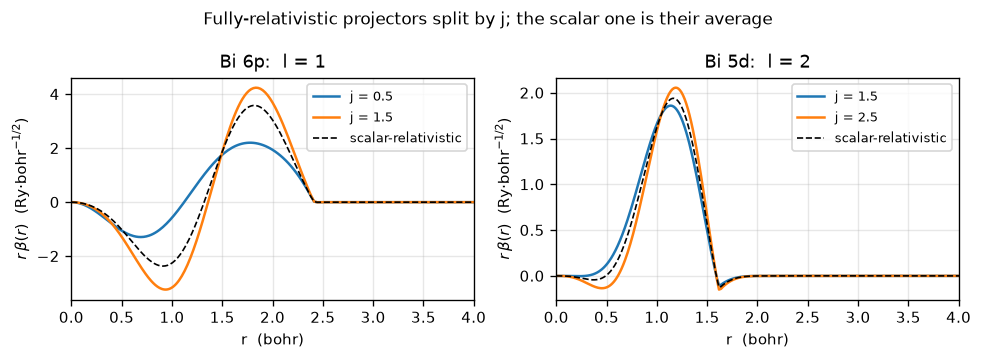

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.0))
r = relativistic.r

for ax, l, label in ((axes[0], 1, "6p"), (axes[1], 2, "5d")):
    for nb, projector in enumerate(relativistic.projectors):
        if projector.l != l:
            continue
        # one radial function per (l, j); the datasets carry two per channel, so
        # take the first of each pair to keep the picture readable
        if any(p.l == l and p.j == projector.j for p in relativistic.projectors[:nb]):
            continue
        ax.plot(r, projector.beta, label=f"j = {projector.j:g}")
    scalar_beta = next(p for p in scalar.projectors if p.l == l)
    ax.plot(r, scalar_beta.beta, "k--", lw=1.0, label="scalar-relativistic")
    ax.set_xlim(0, 4.0)
    ax.set_xlabel("r  (bohr)")
    ax.set_ylabel(r"$r\,\beta(r)$  (Ry$\cdot$bohr$^{-1/2}$)")
    ax.set_title(f"Bi {label}:  l = {l}")
    ax.legend(fontsize=8)
fig.suptitle("Fully-relativistic projectors split by j; the scalar one is their average",
             fontsize=10)
plt.show()


## 2. `fcoef`: from `(l, j)` to a spin matrix

The nonlocal potential is diagonal in the `|l, j, m_j>` basis, where it was
generated. The plane-wave code works in a different basis: real spherical
harmonics times a spin index. The bridge is the matrix QE calls `fcoef`,

    F^{s1 s2}_{ih kh} = sum_m U_{m mi} C^{s1}_{ljm} conj(U_{m mk}) C^{s2}_{ljm}

with `U` (`rot_ylm`) taking real harmonics to complex ones and `C` (`spinor`)
the Clebsch-Gordan coefficient of the spin-angle function. Every spin-orbit
quantity in the code is that one matrix sandwiching a scalar one:

    D^{s1 s2}   = D^(0) F^{s1 s2}                          (`dvan_so`)
    q^{s1 s2}   = sum_s F^{s1 s} q F^{s s2}                (`transform_qq_so`)

`fcoef` is not something to take on trust, because it has an exact
characterisation: **for each radial projector it is the orthogonal projector
onto that `(l, j)` shell**, written in the (real harmonic x spin) basis. So it
must be Hermitian, idempotent, of trace `2j+1`, and the two `j` shells of one
`l` must add up to the identity. Those four together pin down `rot_ylm`,
`spinor` and `sph_ind` at once -- no reference output required.

In [4]:
coupling = SpinOrbitCoupling(relativistic)
from pypresso.pseudo.spinorbit import _channel_table

indv = _channel_table(relativistic)[0]


def shell(nb):
    """fcoef restricted to one radial projector, as a (2n, 2n) matrix."""
    rows = np.flatnonzero(indv == nb)
    block = coupling.fcoef[np.ix_(rows, rows)]
    n = len(rows)
    return np.transpose(block, (0, 2, 1, 3)).reshape(2 * n, 2 * n)


print(f"{'beta':>5s} {'l':>2s} {'j':>4s}   {'Hermitian':>9s} {'idempotent':>10s} "
      f"{'trace':>7s} {'2j+1':>5s}")
for nb, projector in enumerate(relativistic.projectors):
    p = shell(nb)
    print(f"{nb:>5d} {projector.l:>2d} {projector.j:>4g}   "
          f"{str(np.allclose(p, p.conj().T)):>9s} {str(np.allclose(p @ p, p)):>10s} "
          f"{np.trace(p).real:>7.3f} {2 * projector.j + 1:>5.0f}")

print()
for l in (0, 1, 2):
    first = {}
    for nb, projector in enumerate(relativistic.projectors):
        if projector.l == l:
            first.setdefault(projector.j, shell(nb))
    total = sum(first.values())
    print(f"l = {l}:  sum over j = {sorted(first)} is the identity: "
          f"{np.allclose(total, np.eye(total.shape[0]))}")


 beta  l    j   Hermitian idempotent   trace  2j+1
    0  0  0.5        True       True   2.000     2
    1  0  0.5        True       True   2.000     2
    2  1  0.5        True       True   2.000     2
    3  1  1.5        True       True   4.000     4
    4  1  0.5        True       True   2.000     2
    5  1  1.5        True       True   4.000     4
    6  2  1.5        True       True   4.000     4
    7  2  2.5        True       True   6.000     6
    8  2  1.5        True       True   4.000     4
    9  2  2.5        True       True   6.000     6

l = 0:  sum over j = [0.5] is the identity: True
l = 1:  sum over j = [0.5, 1.5] is the identity: True
l = 2:  sum over j = [1.5, 2.5] is the identity: True


And here is what it does to `D_ij`. For the 6p shell of bismuth, the file's
`D^(0)` is a single number per `(l, j)` channel; after the transform it is a 2x2
block matrix in spin space whose **off-diagonal blocks are non-zero and
complex**. Those blocks are the spin-orbit coupling, and everything else in this
notebook follows from them.

/u/40/ladovj1/unix/apps/anaconda3/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


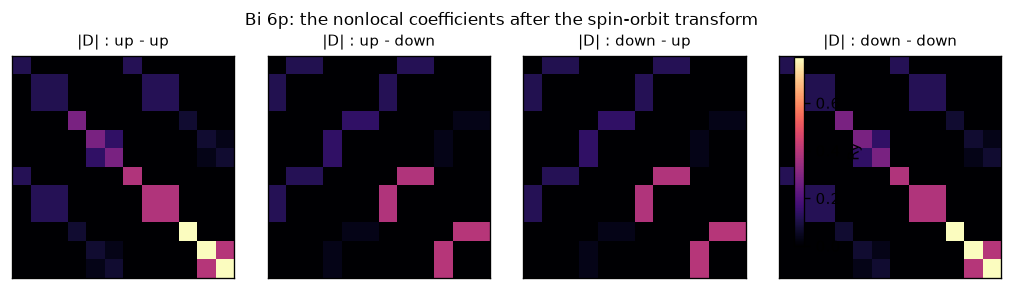

largest off-diagonal (spin-mixing) element: 0.3957 Ry
largest diagonal element:                   0.7914 Ry


In [5]:
rows = np.flatnonzero((_channel_table(relativistic)[1] == 1))  # the l = 1 channels
d = coupling.dvan_so[np.ix_(rows, rows)]  # (n, n, 2, 2)

fig, axes = plt.subplots(1, 4, figsize=(8.6, 2.4))
names = [("up", "up"), ("up", "down"), ("down", "up"), ("down", "down")]
scale = np.abs(d).max()
for ax, (s1, s2), (i, j) in zip(axes, names, [(0, 0), (0, 1), (1, 0), (1, 1)]):
    image = ax.imshow(np.abs(d[:, :, i, j]), vmin=0, vmax=scale, cmap="magma")
    ax.set_title(f"|D| : {s1} - {s2}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(image, ax=axes, shrink=0.85, label="Ry")
fig.suptitle("Bi 6p: the nonlocal coefficients after the spin-orbit transform", fontsize=10)
plt.show()

off = np.abs(d[:, :, 0, 1]).max()
print(f"largest off-diagonal (spin-mixing) element: {off:.4f} Ry")
print(f"largest diagonal element:                   {np.abs(d[:, :, 0, 0]).max():.4f} Ry")


## 3. The check that comes first: switch the coupling off

Before any spin-orbit number is worth looking at, the *spinor* machinery has to
be right -- the doubled Hamiltonian, the doubled eigensolver, the density built
from two components, the projector occupations, the k-point weights. There is a
check for exactly that which needs no reference output at all:

> A noncollinear calculation with no spin-orbit coupling and no magnetization is
> the same physics as an unpolarized one, done in a space twice as large. It must
> reproduce the collinear total energy **term by term**, and every eigenvalue
> must come out **exactly twice**.

Any error in the spinor path breaks it, and nothing about Quantum ESPRESSO is
involved, so a failure is unambiguously this code's. Here it is on the silicon
cell from notebook 1, run both ways.

In [6]:
import tempfile

text = (QE / "pw_scf" / "scf.in").read_text()
marker = text.lower().index("&system") + len("&system")
smeared = text[:marker] + "\n    occupations='smearing', smearing='gaussian', degauss=0.02,\n" + text[marker:]
noncollinear_text = smeared[:marker] + "\n    noncolin = .true.,\n" + smeared[marker:]

work = Path(tempfile.mkdtemp())
(work / "collinear.in").write_text(smeared)
(work / "noncollinear.in").write_text(noncollinear_text)

collinear_system, pseudos = load(work / "collinear.in")
spinor_system, _ = load(work / "noncollinear.in")
print(f"collinear:     nspin={collinear_system.nspin}  npol={collinear_system.npol}  "
      f"nspin_mag={collinear_system.nspin_mag}")
print(f"noncollinear:  nspin={spinor_system.nspin}  npol={spinor_system.npol}  "
      f"nspin_mag={spinor_system.nspin_mag}   <- one component: no magnetization to carry")

collinear = run_scf(collinear_system, pseudos, conv_thr=1e-10, max_iterations=80)
spinor = run_scf(spinor_system, pseudos, conv_thr=1e-10, max_iterations=80)


collinear:     nspin=1  npol=1  nspin_mag=1
noncollinear:  nspin=4  npol=2  nspin_mag=1   <- one component: no magnetization to carry


In [7]:
print(f"{'term':>14s} {'collinear':>18s} {'noncollinear':>18s} {'difference':>12s}")
for term, value in collinear.energy_terms.items():
    other = spinor.energy_terms[term]
    print(f"{term:>14s} {value:>18.12f} {other:>18.12f} {other - value:>12.1e}")
print(f"{'TOTAL':>14s} {collinear.total_energy:>18.12f} {spinor.total_energy:>18.12f} "
      f"{spinor.total_energy - collinear.total_energy:>12.1e}")

doubled = np.repeat(collinear.eigenvalues, 2, axis=1)
n = doubled.shape[1]
print(f"\neigenvalues: {collinear.eigenvalues.shape[1]} bands -> "
      f"{spinor.eigenvalues.shape[1]}, max |difference from doubling| = "
      f"{np.abs(spinor.eigenvalues[:, :n] - doubled).max() * RY_TO_EV:.2e} eV")
print("first six levels at k1 (eV):")
print("  collinear   ", np.round(collinear.eigenvalues[0, :3] * RY_TO_EV, 6))
print("  noncollinear", np.round(spinor.eigenvalues[0, :6] * RY_TO_EV, 6))


          term          collinear       noncollinear   difference
  one-electron     4.833721601574     4.833721601574     -5.3e-15
       hartree     1.084391608208     1.084391608208     -2.2e-16
            xc    -4.812850203017    -4.812850203017      1.8e-15
         ewald   -16.899758577223   -16.899758577223      0.0e+00
      smearing    -0.000000000418    -0.000000000418     -1.0e-19
         TOTAL   -15.794495570876   -15.794495570876     -3.6e-15

eigenvalues: 8 bands -> 16, max |difference from doubling| = 6.04e-14 eV
first six levels at k1 (eV):
  collinear    [-4.870524  2.378738  5.536558]
  noncollinear [-4.870524 -4.870524  2.378738  2.378738  5.536558  5.536558]


Identical to twelve digits, and the bands are exactly paired. The pairing here
is *trivial* degeneracy -- the two spin components never talk to each other --
and the point of switching the coupling on is to see it survive for a different,
non-trivial reason, or break.

## 4. Platinum: the 5d manifold splits

Platinum is the case QE's own test suite uses (`pw_spinorbit/`): one heavy atom
in an fcc cell, ultrasoft, with a fully-relativistic dataset. It is a metal, so
the run needs smearing, and the 5d states sit right at the Fermi level where the
splitting is easy to see.

In [8]:
pt_system, pt_pseudos = load(QE / "pw_spinorbit" / "spinorbit.in")
pt_reference = read_qe_output(CASES / "reference.out.pw_spinorbit-spinorbit")
print(f"lspinorb={pt_system.lspinorb}  nspin={pt_system.nspin}  npol={pt_system.npol}  "
      f"nspin_mag={pt_system.nspin_mag}  k-points={pt_system.kpoints.nk}")
print(f"k-point weights sum to {float(np.sum(pt_system.kpoints.weights)):.3f}"
      "  <- one, not two: a spinor band holds one electron")

pt = run_scf(pt_system, pt_pseudos, conv_thr=1e-10, max_iterations=80)
print(f"\nconverged in {pt.iterations} iterations")
print(f"{'term':>14s} {'pypresso':>18s} {'QE 7.5':>18s} {'difference':>12s}")
for term, value in pt.energy_terms.items():
    other = pt_reference.energy_terms.get(term)
    if other is not None:
        print(f"{term:>14s} {value:>18.9f} {other:>18.9f} {value - other:>12.1e}")
print(f"{'TOTAL':>14s} {pt.total_energy:>18.9f} {pt_reference.total_energy:>18.9f} "
      f"{pt.total_energy - pt_reference.total_energy:>12.1e}")
print(f"\nFermi energy: {pt.fermi_energy * RY_TO_EV:.4f} eV   "
      f"QE {pt_reference.fermi_energy:.4f} eV")


lspinorb=True  nspin=4  npol=2  nspin_mag=1  k-points=10
k-point weights sum to 1.000  <- one, not two: a spinor band holds one electron



converged in 8 iterations
          term           pypresso             QE 7.5   difference
  one-electron       17.067101011       17.067099220      1.8e-06
       hartree        3.770779573        3.770783580     -4.0e-06
            xc      -28.536694723      -28.536696950      2.2e-06
         ewald      -61.790593995      -61.790593990     -4.8e-09
      smearing       -0.002121373       -0.002121370     -2.9e-09
         TOTAL      -69.491529507      -69.491529520      1.3e-08

Fermi energy: 17.6822 eV   QE 17.6822 eV


Two things to notice in the eigenvalues.

**Every level is doubly degenerate**, even though the spin-orbit coupling is
large. That is not an accident and not a leftover of the previous section: fcc
platinum has **inversion symmetry**, and time reversal together with inversion
forces Kramers pairs to sit at the *same* k-point. A spurious splitting here
would mean a non-Hermitian `D` or a mis-paired spin block -- the failure mode
that looks like a physical result.

**The 5d manifold is spread over more than an eV.** With the coupling switched
off, the five d orbitals at a general k-point would be split only by the crystal
field; here they are split by `j` as well.

In [9]:
levels = np.asarray(pt.eigenvalues)[0] * RY_TO_EV
pairs = levels[0::2]
print("Kramers pairs at the first k-point (eV):")
for n, (a, b) in enumerate(zip(levels[0::2], levels[1::2])):
    print(f"  pair {n:>2d}: {a:9.4f}  {b:9.4f}   splitting {abs(a - b):.2e}")
print(f"\nmax Kramers splitting over all k: "
      f"{np.abs(np.asarray(pt.eigenvalues)[:, 0::2] - np.asarray(pt.eigenvalues)[:, 1::2]).max() * RY_TO_EV:.1e} eV")
print(f"5d manifold (first six pairs) spans {pairs[:6].max() - pairs[:6].min():.3f} eV")


Kramers pairs at the first k-point (eV):
  pair  0:    7.8772     7.8772   splitting 3.55e-14
  pair  1:   13.2293    13.2293   splitting 6.75e-14
  pair  2:   13.4266    13.4266   splitting 5.86e-14
  pair  3:   14.4377    14.4377   splitting 1.95e-14
  pair  4:   15.9226    15.9226   splitting 4.97e-14
  pair  5:   16.1363    16.1363   splitting 3.20e-14
  pair  6:   35.3889    35.3889   splitting 7.11e-15
  pair  7:   36.0586    36.0586   splitting 2.13e-14
  pair  8:   39.4165    39.4165   splitting 7.82e-14

max Kramers splitting over all k: 1.1e-13 eV
5d manifold (first six pairs) spans 8.259 eV


The same run on the other two pseudopotential kinds -- ultrasoft with PBE, and
PAW -- against their own references. All three matter: the spin transform enters
`qq_so` (the overlap operator), `newd_so` (the self-consistent `D_ij`) and
`add_becsum_so` (the projector occupations) in different ways, and PAW adds a
one-centre term on top of all of them.

In [10]:
PLATINUM = [
    ("spinorbit.in", "pw_spinorbit-spinorbit", "ultrasoft, LDA"),
    ("spinorbit-pbe.in", "pw_spinorbit-spinorbit-pbe", "ultrasoft, PBE"),
    ("spinorbit-paw.in", "pw_spinorbit-spinorbit-paw", "PAW, PBE"),
]

rows = []
for name, stem, label in PLATINUM:
    system, pseudos = load(QE / "pw_spinorbit" / name)
    reference = read_qe_output(CASES / f"reference.out.{stem}")
    result = pt if name == "spinorbit.in" else run_scf(
        system, pseudos, conv_thr=1e-10, max_iterations=100)
    eigen = np.abs(np.asarray(result.eigenvalues) * RY_TO_EV
                   - np.squeeze(np.asarray(reference.eigenvalues))).max()
    rows.append((label, result.total_energy, reference.total_energy, eigen))

print(f"{'dataset':>16s} {'pypresso (Ry)':>18s} {'QE 7.5 (Ry)':>18s} "
      f"{'dE':>10s} {'max de (eV)':>12s}")
for label, mine, theirs, eigen in rows:
    print(f"{label:>16s} {mine:>18.9f} {theirs:>18.9f} "
          f"{mine - theirs:>10.1e} {eigen:>12.1e}")


         dataset      pypresso (Ry)        QE 7.5 (Ry)         dE  max de (eV)
  ultrasoft, LDA      -69.491529507      -69.491529520    1.3e-08      3.6e-04
  ultrasoft, PBE      -90.199533906      -90.199533910    3.8e-09      2.4e-04
        PAW, PBE     -753.342691622     -753.342691630    8.4e-09      1.0e-04


## 5. Bismuthene: a gap made entirely of spin-orbit coupling

Platinum shows that the numbers are right. Bismuthene shows what the feature is
*for*.

**Bismuthene** is a single honeycomb layer of bismuth -- graphene's structure
with the heaviest stable element in place of carbon. Grown on SiC(0001) it is
flat, with the substrate's lattice constant `a = 5.35 A` (Reis *et al.*,
*Science* **357**, 287 (2017)); freestanding bismuth would buckle, so what is
modelled here is that substrate-stabilised geometry without the substrate, which
is the standard way to study it. Only the layer is in the cell, so the substrate
does nothing here beyond fixing the lattice constant.

Its electronic structure is the point. The honeycomb lattice brings the frontier
bands -- the ones built from bismuth's in-plane 6p orbitals -- nearly together
around **K**: with the coupling switched off this calculation leaves them within
a couple of tenths of an eV of each other, at a pair of points flanking K along
M-K-Gamma, which is a semimetal for practical purposes. Bismuth's spin-orbit
coupling is enormous, and it pushes them apart by half an electronvolt. That gap
is what bismuthene is known for -- a quantum spin Hall insulator whose gap is
large enough to matter at room temperature -- though the *topology* is a Z2
invariant this notebook does not compute. What it computes is the gap, and what
the gap is made of.

So the gap here is not a correction to a number. It is the presence of a number
at all, and it is the sharpest demonstration of the feature this code can give.

We run the same cell twice: once with the fully-relativistic dataset and
`lspinorb`, once with the *scalar*-relativistic dataset and no spin at all. Using
the scalar dataset rather than the relativistic one with the coupling switched
off is deliberate -- the second asks QE to `j`-average the projectors, which is a
third pseudopotential and not the one in either file.

Two sizes of the same pair are committed, both with their own QE reference: a
test-sized one at 20 Ry on a 6x6x1 grid, which runs in a few minutes and is what
this notebook executes, and a converged one at 35 Ry on 12x12x1. They tell the
same story -- a fundamental gap of at most a tenth or so of an eV without the
coupling, and about half an eV with it -- and the small cell's coarse path simply
resolves the near-degeneracy less sharply: converged, the gap without the coupling
is 0.040 eV against this cell's 0.14 eV, and with it 0.508 eV against 0.49 eV.
Both converged gaps match QE to the four decimals it prints.

In [11]:
#: Which pair of inputs to run. "-small" is 20 Ry on a 6x6x1 grid and takes a few
#: minutes; "" is the converged pair -- 35 Ry, 12x12x1 -- which takes about forty
#: minutes in total and peaks at 9.4 GB. Both have committed QE references, so the
#: comparison is real either way; the small pair is the one the regression tests
#: check and the one PLAN.md's P14 entry quotes.
SIZE = "-small"

#: Where the path's corners fall, from the 4 / 3 / 5 / 1 segments of the small
#: band input (12 / 7 / 14 / 1 for the converged one).
CORNERS = {"Gamma": 0, "M": 4, "K": 7, "Gamma'": 12} if SIZE else \
          {"Gamma": 0, "M": 12, "K": 19, "Gamma'": 33}

soc_system, soc_pseudos = load(CASES / f"bismuthene-soc{SIZE}.in")
nosoc_system, nosoc_pseudos = load(CASES / f"bismuthene-nosoc{SIZE}.in")

nelec = sum(soc_pseudos[t].z_valence for t in soc_system.structure.types)
cell = soc_system.cell
print(f"a = {cell.alat:.4f} bohr = {cell.alat * 0.529177210903:.3f} A,  "
      f"c = {cell.alat * 1.978248:.3f} bohr,  volume = {float(cell.volume):.1f} bohr^3")
print(f"{soc_system.structure.nat} Bi atoms, {nelec:.0f} valence electrons "
      f"(5d10 6s2 6p3 each)")
print(f"with SOC:     nspin={soc_system.nspin} npol={soc_system.npol} "
      f"nspin_mag={soc_system.nspin_mag}, {soc_system.kpoints.nk} irreducible k-points")
print(f"without SOC:  nspin={nosoc_system.nspin} npol={nosoc_system.npol} "
      f"nspin_mag={nosoc_system.nspin_mag}, {nosoc_system.kpoints.nk} irreducible k-points")


a = 10.1099 bohr = 5.350 A,  c = 20.000 bohr,  volume = 1770.3 bohr^3
2 Bi atoms, 30 valence electrons (5d10 6s2 6p3 each)
with SOC:     nspin=4 npol=2 nspin_mag=1, 7 irreducible k-points
without SOC:  nspin=1 npol=1 nspin_mag=1, 7 irreducible k-points


In [12]:
import time

results = {}
for tag, (system, pseudos) in (("soc", (soc_system, soc_pseudos)),
                               ("nosoc", (nosoc_system, nosoc_pseudos))):
    start = time.time()
    results[tag] = run_scf(system, pseudos, conv_thr=1e-10, max_iterations=100)
    print(f"{tag:>6s}: {results[tag].iterations} iterations, "
          f"{time.time() - start:.0f} s, E = {results[tag].total_energy:.9f} Ry")


   soc: 8 iterations, 121 s, E = -295.610317533 Ry


 nosoc: 9 iterations, 37 s, E = -296.198423399 Ry


In [13]:
print(f"{'':>8s} {'term':>14s} {'pypresso (Ry)':>18s} {'QE 7.5 (Ry)':>18s} {'diff':>11s}")
for tag in ("soc", "nosoc"):
    reference = read_qe_output(CASES / f"reference.out.bismuthene-{tag}{SIZE}")
    result = results[tag]
    for term, value in result.energy_terms.items():
        other = reference.energy_terms.get(term)
        if other is not None:
            print(f"{tag:>8s} {term:>14s} {value:>18.9f} {other:>18.9f} {value - other:>11.1e}")
    print(f"{tag:>8s} {'TOTAL':>14s} {result.total_energy:>18.9f} "
          f"{reference.total_energy:>18.9f} "
          f"{result.total_energy - reference.total_energy:>11.1e}")
    print()


                   term      pypresso (Ry)        QE 7.5 (Ry)        diff
     soc   one-electron     -393.791130466     -393.790436790    -6.9e-04
     soc        hartree      203.672112877      203.671372130     7.4e-04
     soc             xc      -62.251644537      -62.251562340    -8.2e-05
     soc          ewald      -43.239630686      -43.239630690     4.2e-09
     soc       smearing       -0.000024721       -0.000024720    -7.4e-10
     soc          TOTAL     -295.610317533     -295.610282410    -3.5e-05

   nosoc   one-electron     -393.467681671     -393.467058750    -6.2e-04
   nosoc        hartree      203.216004576      203.215344160     6.6e-04
   nosoc             xc      -62.707082245      -62.707011190    -7.1e-05
   nosoc          ewald      -43.239630686      -43.239630690     4.2e-09
   nosoc       smearing       -0.000033374       -0.000033380     6.1e-09
   nosoc          TOTAL     -296.198423399     -296.198389840    -3.4e-05



### The band structure

The path is `Gamma - M - K - Gamma`, and the interesting stretch is `M - K -
Gamma`, where the frontier bands come together. The density is frozen at the
converged one and the Hamiltonian diagonalised once per k-point -- a `bands` run,
notebook 2's machinery, with spinors in it.

In [14]:
bands = {}
for tag, (system, pseudos) in (("soc", (soc_system, soc_pseudos)),
                               ("nosoc", (nosoc_system, nosoc_pseudos))):
    path_system, _ = load(CASES / f"bismuthene-{tag}{SIZE}-bands.in")
    start = time.time()
    bands[tag] = run_bands(path_system, pseudos, results[tag].density,
                           nbnd=path_system.nbnd,
                           fermi_energy=results[tag].fermi_energy)
    print(f"{tag:>6s}: {path_system.kpoints.nk} k-points on the path, "
          f"{time.time() - start:.0f} s")


   soc: 13 k-points on the path, 103 s


 nosoc: 13 k-points on the path, 32 s


In [15]:
#: The topmost bands are where an iterative eigensolver stops, not where the
#: physics is: they sit at the edge of the subspace with nothing above them to
#: mix with, and neither code converges them to the threshold the occupied
#: states meet. Measured here: everything below agrees with QE to 0.46 meV, and
#: these disagree by 10-16 meV. The soc run's come in twos because of Kramers.
UNCONVERGED_TOP = {"soc": 2, "nosoc": 3}

for tag in ("soc", "nosoc"):
    reference = read_qe_output(CASES / f"reference.out.bismuthene-{tag}{SIZE}-bands")
    mine = bands[tag].eigenvalues_ev
    theirs = np.squeeze(np.asarray(reference.eigenvalues))
    n = min(mine.shape[1], theirs.shape[1])
    converged = n - UNCONVERGED_TOP[tag]
    print(f"{tag:>6s}: bands vs QE over {mine.shape[0]} k-points, max |difference| = "
          f"{np.abs(mine[:, :converged] - theirs[:, :converged]).max():.2e} eV "
          f"in the lowest {converged} bands, "
          f"{np.abs(mine[:, :n] - theirs[:, :n]).max():.2e} eV including the top "
          f"{UNCONVERGED_TOP[tag]}")

   soc: bands vs QE over 13 k-points, max |difference| = 4.44e-04 eV in the lowest 34 bands, 1.07e-02 eV including the top 2
 nosoc: bands vs QE over 13 k-points, max |difference| = 4.59e-04 eV in the lowest 17 bands, 1.62e-02 eV including the top 3


In [16]:
def gaps(tag):
    """Occupied bands, the smallest direct gap on the path, and the fundamental gap."""
    system, _ = load(CASES / f"bismuthene-{tag}{SIZE}-bands.in")
    levels = bands[tag].eigenvalues_ev
    # A spinor band holds one electron; a spin-degenerate one holds two.
    occupied = int(round(nelec / (1 if system.nspin == 4 else 2)))
    valence, conduction = levels[:, occupied - 1], levels[:, occupied]
    direct = conduction - valence
    return occupied, float(direct.min()), int(direct.argmin()), float(conduction.min() - valence.max())


for tag in ("soc", "nosoc"):
    occupied, direct, where, fundamental = gaps(tag)
    print(f"{tag:>6s}: {occupied:>2d} occupied bands   smallest direct gap {direct:6.4f} eV "
          f"at k-point {where:>2d} of {bands[tag].eigenvalues_ev.shape[0]}   "
          f"fundamental gap {fundamental:+7.4f} eV")
print(f"\n(K is k-point {CORNERS['K']} on this path, M is {CORNERS['M']}: "
      "the bands come closest beside K, not at it)")

   soc: 30 occupied bands   smallest direct gap 0.6295 eV at k-point  5 of 13   fundamental gap +0.4913 eV
 nosoc: 15 occupied bands   smallest direct gap 0.1361 eV at k-point  6 of 13   fundamental gap +0.1361 eV

(K is k-point 7 on this path, M is 4: the bands come closest beside K, not at it)


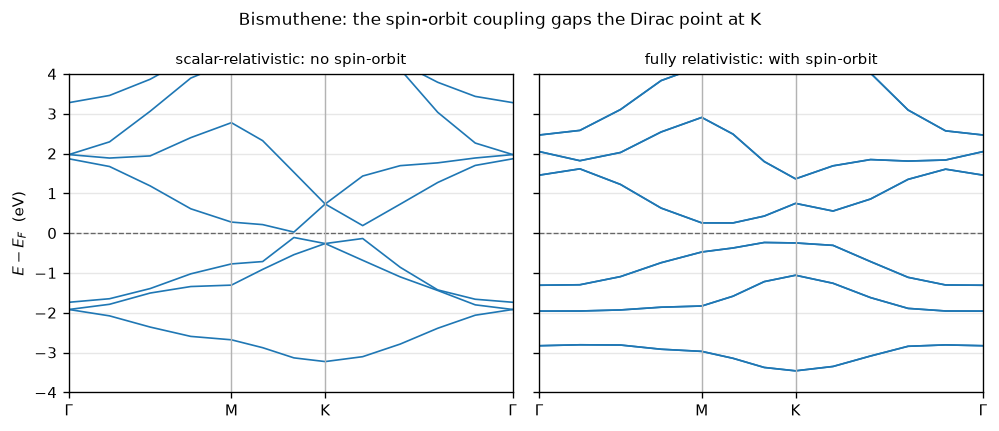

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), sharey=True)
labels = [r"$\Gamma$", "M", "K", r"$\Gamma$"]

for ax, tag, title in ((axes[0], "nosoc", "scalar-relativistic: no spin-orbit"),
                       (axes[1], "soc", "fully relativistic: with spin-orbit")):
    structure = bands[tag]
    x = structure.path_length
    fermi = results[tag].fermi_energy * RY_TO_EV
    ax.plot(x, structure.eigenvalues_ev - fermi, color="#1f77b4", lw=1.0)
    ax.axhline(0.0, color="0.4", lw=0.8, ls="--")
    # tick marks at the path corners
    corners = list(CORNERS.values())
    for c in corners[1:-1]:
        ax.axvline(x[c], color="0.7", lw=0.8)
    ax.set_xticks([x[c] for c in corners])
    ax.set_xticklabels(labels)
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(-4.0, 4.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("")
axes[0].set_ylabel(r"$E - E_F$  (eV)")
fig.suptitle("Bismuthene: the spin-orbit coupling gaps the Dirac point at K", fontsize=10)
plt.show()


The left panel is a semimetal for practical purposes: the two frontier bands
come within a couple of tenths of an eV of each other just off K, and what
separates the valence maximum from the conduction minimum is smaller still. The
right panel is an insulator with half an electronvolt of gap, and the difference
between them is made of nothing but the `j`-resolved projectors -- the cell, the
cutoffs, the k-points and the functional are the same in both.

Worth being precise about *where*, since the honeycomb lattice invites the
graphene answer: the bands do not meet exactly at K, where they are already
split, but at a pair of points flanking it along M-K and K-Gamma. That is where
the coupling does its work, and it is why the quantity printed above is the
smallest gap on the path rather than the gap at one symmetry point.

One more property worth checking. Planar bismuthene has **inversion symmetry**
(the two sublattices map into each other through the cell centre), so, exactly as
in platinum, Kramers degeneracy survives the coupling and every band on the path
stays doubly degenerate. In a *buckled* layer, or on a substrate, inversion is
broken and the same spin-orbit coupling would split them -- which is the Rashba
effect.

In [18]:
levels = bands["soc"].eigenvalues_ev
splitting = np.abs(levels[:, 0::2] - levels[:, 1::2]).max()
print(f"max Kramers splitting on the whole path: {splitting:.2e} eV")
print("(inversion + time reversal; it is round-off, not physics)")


max Kramers splitting on the whole path: 1.67e-08 eV
(inversion + time reversal; it is round-off, not physics)


## 6. Summary

Everything this notebook computed, against Quantum ESPRESSO 7.5 -- every
reference regenerated with the vendored `pw.x` at `conv_thr = 1e-10`.

In [19]:
summary = [(f"Pt fcc, {label}", mine, theirs) for label, mine, theirs, _ in rows]
for tag, label in (("soc", "bismuthene, with SOC"), ("nosoc", "bismuthene, no SOC")):
    reference = read_qe_output(CASES / f"reference.out.bismuthene-{tag}{SIZE}")
    summary.append((label, results[tag].total_energy, reference.total_energy))

print(f"{'case':>28s} {'pypresso (Ry)':>18s} {'QE 7.5 (Ry)':>18s} {'difference':>12s}")
for name, mine, theirs in summary:
    print(f"{name:>28s} {mine:>18.9f} {theirs:>18.9f} {mine - theirs:>12.1e}")

print()
for tag in ("nosoc", "soc"):
    _, direct, _, fundamental = gaps(tag)
    print(f"bismuthene, {tag:>5s}: smallest direct gap {direct:6.4f} eV, "
          f"fundamental gap {fundamental:+7.4f} eV")

                        case      pypresso (Ry)        QE 7.5 (Ry)   difference
      Pt fcc, ultrasoft, LDA      -69.491529507      -69.491529520      1.3e-08
      Pt fcc, ultrasoft, PBE      -90.199533906      -90.199533910      3.8e-09
            Pt fcc, PAW, PBE     -753.342691622     -753.342691630      8.4e-09
        bismuthene, with SOC     -295.610317533     -295.610282410     -3.5e-05
          bismuthene, no SOC     -296.198423399     -296.198389840     -3.4e-05

bismuthene, nosoc: smallest direct gap 0.1361 eV, fundamental gap +0.1361 eV
bismuthene,   soc: smallest direct gap 0.6295 eV, fundamental gap +0.4913 eV


What made the feature tractable is the second row of the table at the top of this
notebook: a *nonmagnetic* spin-orbit run has `nspin_mag = 1`, so the density, the
potential, the exchange-correlation functional, the mixer and the symmetrisation
never learn that anything changed. The entire implementation is the spinor
Hamiltonian and the `fcoef` transform -- two new modules, and no edit to the
collinear hot path.

`PLAN.md`'s P14 entry records the transcription traps, of which two were latent
bugs in code older than this work and only a fully-relativistic PAW dataset could
reach them.